# Comparaison CAE vs VAE — Version Finale

**Corrections et améliorations :**
- Triple split strict 70/20/10
- Normalisation calculée sur X_train uniquement (pas de data leakage)
- VAE avec `test_step` → EarlyStopping sur `val_loss`
- Segment de reconstruction extrait AVANT le shuffle (signal continu réel)
- Reconstruction et génération affichées sur les 3 axes
- Inférence VAE cohérente avec l'entraînement (z échantillonné)

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import time

## 1. Chargement et fenêtrage

On récupère un segment continu AVANT le shuffle pour la visualisation finale.
Ce segment ne sera jamais utilisé pour l'entraînement.

In [2]:
path = "D:/IMDS/MALMO/IMU_LM_Data/data/merged_dataset/filtered_activities_dataset.parquet"
df = pd.read_parquet(path)

features = ["acc_x", "acc_y", "acc_z"]
df = df[["timestamp_ns", "dataset", "subject_id", "session_id", "global_activity_id"] + features]

# Passage à 25Hz
df = df.iloc[::2].copy()
df[features] = df[features].interpolate(method='linear').bfill().ffill()

WINDOW_SIZE = 50   # 2 secondes à 25Hz
STRIDE      = 25   # overlap 50%
N_WINDOWS   = 30   # 30 x 2s = 60 secondes

# --- Paramètre à adapter selon tes vrais global_activity_id ---
TARGET_LABEL = 1
LABEL_NAME   = "Marche"
axis_names   = ["acc_x", "acc_y", "acc_z"]

# ---------------------------------------------------------------
# Extraction du segment continu AVANT le shuffle
# On cherche la première session qui contient au moins 30 fenêtres
# consécutives du label cible
# ---------------------------------------------------------------
segment_continu = None

for _, group in df.groupby(["dataset", "subject_id", "session_id"]):
    sig  = group.sort_values("timestamp_ns")[features].values
    acts = group.sort_values("timestamp_ns")["global_activity_id"].values

    wins, win_labels = [], []
    for i in range(0, len(sig) - WINDOW_SIZE, STRIDE):
        lbl = np.bincount(acts[i:i + WINDOW_SIZE]).argmax()
        wins.append(sig[i:i + WINDOW_SIZE])
        win_labels.append(lbl)

    wins       = np.array(wins,       dtype=np.float32)
    win_labels = np.array(win_labels)

    # Chercher une séquence de N_WINDOWS fenêtres consécutives du label cible
    count, start = 0, 0
    for idx in range(len(win_labels)):
        if win_labels[idx] == TARGET_LABEL:
            if count == 0:
                start = idx
            count += 1
            if count >= N_WINDOWS:
                segment_continu = wins[start:start + N_WINDOWS]  # (30, 50, 3)
                break
        else:
            count = 0
    if segment_continu is not None:
        break

if segment_continu is None:
    raise ValueError(f"Pas assez de fenêtres consécutives pour le label {TARGET_LABEL}. "
                     f"Réduis N_WINDOWS ou change TARGET_LABEL.")

print(f"Segment continu '{LABEL_NAME}' trouvé : {segment_continu.shape}")

# ---------------------------------------------------------------
# Fenêtrage complet pour l'entraînement
# ---------------------------------------------------------------
X, labels = [], []
print("Création des fenêtres d'entraînement...")
for _, group in df.groupby(["dataset", "subject_id", "session_id"]):
    sig  = group.sort_values("timestamp_ns")[features].values
    acts = group.sort_values("timestamp_ns")["global_activity_id"].values
    for i in range(0, len(sig) - WINDOW_SIZE, STRIDE):
        X.append(sig[i:i + WINDOW_SIZE])
        labels.append(np.bincount(acts[i:i + WINDOW_SIZE]).argmax())

X      = np.array(X, dtype=np.float32)
labels = np.array(labels)
print(f"Dataset complet : {X.shape}  —  {len(np.unique(labels))} labels uniques")

Segment continu 'Marche' trouvé : (30, 50, 3)
Création des fenêtres d'entraînement...
Dataset complet : (211039, 50, 3)  —  3 labels uniques


## 2. Triple split 70 / 20 / 10 + normalisation sans data leakage

- Split AVANT normalisation
- `X_mean` et `X_std` calculés uniquement sur `X_train`
- Mêmes paramètres appliqués à `X_val`, `X_test` et `segment_continu`

In [3]:
# Étape 1 : isoler 10% de test final
X_temp, X_test, y_temp, y_test = train_test_split(
    X, labels, test_size=0.10, random_state=42, stratify=labels
)

# Étape 2 : 22.22% du reste → validation (≈ 20% du total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2222, random_state=42, stratify=y_temp
)

# Normalisation calculée UNIQUEMENT sur X_train
X_mean = np.mean(X_train, axis=(0, 1))  # shape (3,)
X_std  = np.std(X_train,  axis=(0, 1))  # shape (3,)

X_train         = (X_train         - X_mean) / (X_std + 1e-7)
X_val           = (X_val           - X_mean) / (X_std + 1e-7)
X_test          = (X_test          - X_mean) / (X_std + 1e-7)
segment_continu = (segment_continu - X_mean) / (X_std + 1e-7)  # même normalisation

print(f"Train : {len(X_train):>7} fenêtres")
print(f"Val   : {len(X_val):>7} fenêtres")
print(f"Test  : {len(X_test):>7} fenêtres")

Train :  147731 fenêtres
Val   :   42204 fenêtres
Test  :   21104 fenêtres


## 3. Hyperparamètres et architectures

In [4]:
timesteps  = 50
n_features = 3
latent_dim = 32
EPOCHS     = 150
BATCH_SIZE = 256
PATIENCE   = 8

def get_encoder_cae():
    inputs = layers.Input(shape=(timesteps, n_features))
    x = layers.Conv1D(32,  5, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)                                     # 50 → 25
    x = layers.Conv1D(64,  3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)                                     # 25 → 12
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    latent = layers.Dense(latent_dim, name="cae_latent")(x)
    return Model(inputs, latent, name="Encoder_CAE")

def get_encoder_vae():
    inputs = layers.Input(shape=(timesteps, n_features))
    x = layers.Conv1D(32,  5, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64,  3, activation='relu', padding='same')(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    return Model(inputs, [z_mean, z_log_var], name="Encoder_VAE")

def get_decoder(name):
    inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(12 * 128, activation='relu')(inputs)
    x = layers.Reshape((12, 128))(x)
    x = layers.UpSampling1D(2)(x)                                     # 12 → 24
    x = layers.Conv1D(64, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling1D(2)(x)                                     # 24 → 48
    x = layers.ZeroPadding1D(padding=(1, 1))(x)                       # 48 → 50
    x = layers.Conv1D(32, 5, activation='relu', padding='same')(x)
    outputs = layers.Conv1D(n_features, 5, activation='linear', padding='same')(x)
    return Model(inputs, outputs, name=name)

## 4. Entraînement CAE

In [5]:
print("--- ENTRAÎNEMENT CAE ---")
cae_encoder = get_encoder_cae()
cae_decoder = get_decoder("Decoder_CAE")
cae_model   = Model(cae_encoder.input, cae_decoder(cae_encoder.output))
cae_model.compile(optimizer='adam', loss='mse')

t0 = time.time()
history_cae = cae_model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE, restore_best_weights=True
        )
    ]
)
time_cae = time.time() - t0
print(f"CAE entraîné en {time_cae:.1f}s")

--- ENTRAÎNEMENT CAE ---
Epoch 1/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.1015 - val_loss: 0.0628
Epoch 2/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0557 - val_loss: 0.0522
Epoch 3/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - loss: 0.0504 - val_loss: 0.0502
Epoch 4/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 47s 49ms/step - loss: 0.0484 - val_loss: 0.0470
Epoch 5/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - loss: 0.0472 - val_loss: 0.0476
Epoch 6/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - loss: 0.0461 - val_loss: 0.0485
Epoch 7/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - loss: 0.0455 - val_loss: 0.0439
Epoch 8/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0448 - val_loss: 0.0448
Epoch 9/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0441 - val_loss: 0.0428
Epoch 10/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0426 - val_loss: 0.0445
Epoch 11/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0415 - val_loss: 0.0425


## 5. Entraînement VAE

In [6]:
class BetaVAE(Model):
    def __init__(self, encoder, decoder, beta=0.01, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon")
        self.kl_loss_tracker    = tf.keras.metrics.Mean(name="kl")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_loss(self, data):
        zm, zv = self.encoder(data)
        z      = zm + 0.1 * tf.exp(0.5 * zv) * tf.random.normal(tf.shape(zm))
        recon  = self.decoder(z)
        r_loss  = tf.reduce_mean(tf.reduce_sum(tf.keras.losses.mse(data, recon), axis=-1))
        kl_loss = -0.5 * tf.reduce_mean(1 + zv - tf.square(zm) - tf.exp(zv))
        return r_loss + self.beta * kl_loss, r_loss, kl_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total, r_loss, kl_loss = self._compute_loss(data)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total)
        self.recon_loss_tracker.update_state(r_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        total, r_loss, kl_loss = self._compute_loss(data)
        self.total_loss_tracker.update_state(total)
        self.recon_loss_tracker.update_state(r_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


print("--- ENTRAÎNEMENT VAE ---")
vae_enc   = get_encoder_vae()
vae_dec   = get_decoder("Decoder_VAE")
vae_model = BetaVAE(vae_enc, vae_dec, beta=0.01)
vae_model.compile(optimizer=tf.keras.optimizers.Adam())

t0 = time.time()
history_vae = vae_model.fit(
    X_train,
    validation_data=(X_val,),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE, restore_best_weights=True
        )
    ]
)
time_vae = time.time() - t0
print(f"VAE entraîné en {time_vae:.1f}s")

--- ENTRAÎNEMENT VAE ---
Epoch 1/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 38s 58ms/step - kl: 1.9449 - loss: 4.9421 - recon: 4.9226 - val_kl: 2.1675 - val_loss: 2.9816 - val_recon: 2.9599
Epoch 2/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - kl: 2.1716 - loss: 2.8021 - recon: 2.7803 - val_kl: 2.1552 - val_loss: 2.7177 - val_recon: 2.6962
Epoch 3/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - kl: 2.1706 - loss: 2.5324 - recon: 2.5107 - val_kl: 2.1722 - val_loss: 2.4814 - val_recon: 2.4597
Epoch 4/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - kl: 2.1247 - loss: 2.4577 - recon: 2.4364 - val_kl: 2.1258 - val_loss: 2.4036 - val_recon: 2.3824
Epoch 5/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - kl: 2.0843 - loss: 2.4034 - recon: 2.3826 - val_kl: 2.0840 - val_loss: 2.3578 - val_recon: 2.3370
Epoch 6/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - kl: 2.0411 - loss: 2.3541 - recon: 2.3337 - val_kl: 1.9663 - val_loss: 2.3764 - val_recon: 2.3568
Epoch 7/150
578/578 ━━━━━━━━━━━━━━━━━━━━ 30s 

## 6. Courbes d'apprentissage

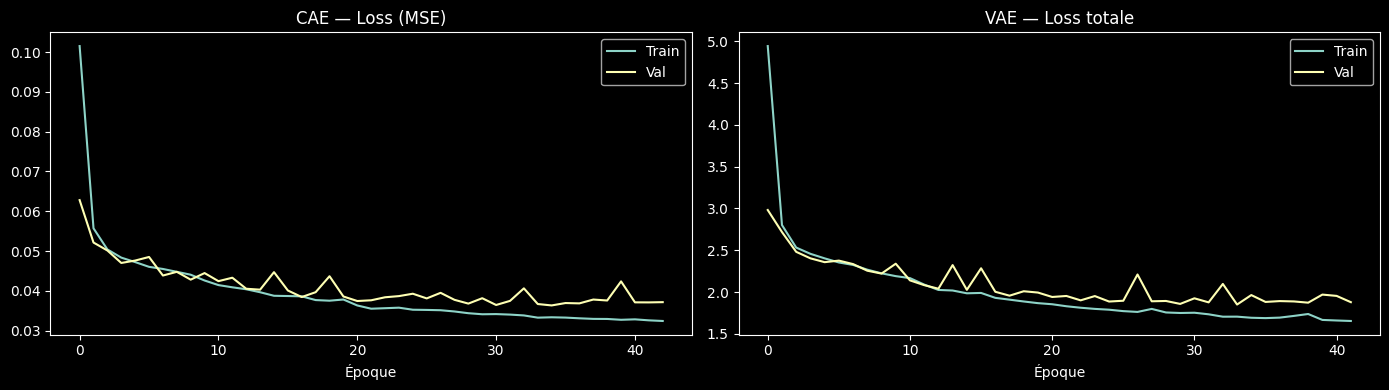

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_cae.history['loss'],     label='Train')
axes[0].plot(history_cae.history['val_loss'], label='Val')
axes[0].set_title("CAE — Loss (MSE)")
axes[0].set_xlabel("Époque")
axes[0].legend()

axes[1].plot(history_vae.history['loss'],     label='Train')
axes[1].plot(history_vae.history['val_loss'], label='Val')
axes[1].set_title("VAE — Loss totale")
axes[1].set_xlabel("Époque")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Évaluation finale sur le test set

In [8]:
# CAE
mse_cae = cae_model.evaluate(X_test, X_test, verbose=0)

# VAE — z échantillonné (cohérent avec l'entraînement)
zm_test, zv_test = vae_enc.predict(X_test, verbose=0)
z_test           = zm_test + 0.1 * np.exp(0.5 * zv_test) * np.random.normal(size=zm_test.shape)
recon_vae_test   = vae_dec.predict(z_test.astype(np.float32), verbose=0)
mse_vae          = np.mean(np.square(X_test - recon_vae_test))

print("=" * 48)
print(f"RÉSULTATS FINAUX  (Test set : {len(X_test)} fenêtres)")
print("=" * 48)
print(f"CAE  →  Temps : {time_cae:.1f}s  |  MSE test : {mse_cae:.6f}")
print(f"VAE  →  Temps : {time_vae:.1f}s  |  MSE test : {mse_vae:.6f}")

RÉSULTATS FINAUX  (Test set : 21104 fenêtres)
CAE  →  Temps : 1200.2s  |  MSE test : 0.037509
VAE  →  Temps : 1041.2s  |  MSE test : 0.038039


## 8. t-SNE sur l'espace latent (test set)

Calcul t-SNE...


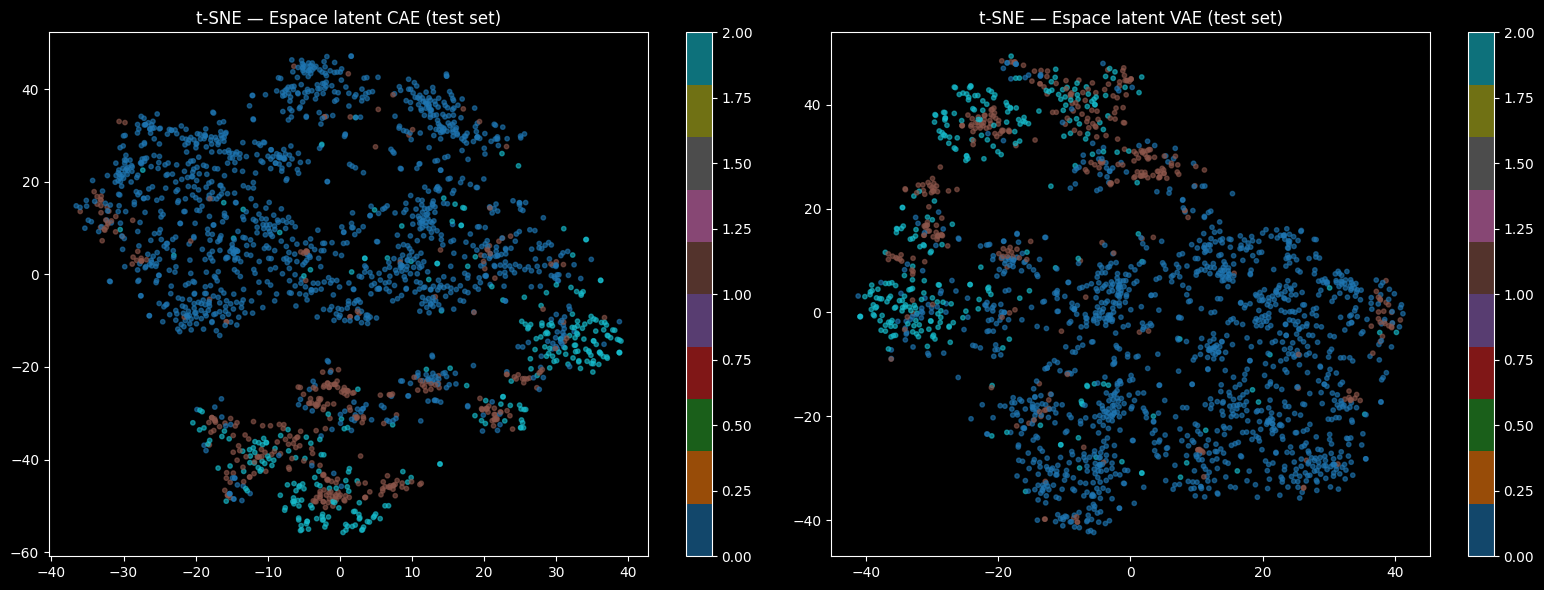

In [9]:
print("Calcul t-SNE...")
n_tsne = min(2000, len(X_test))

lat_cae    = cae_encoder.predict(X_test[:n_tsne], verbose=0)
lat_vae, _ = vae_enc.predict(X_test[:n_tsne], verbose=0)  # z_mean pour t-SNE (déterministe)

tsne    = TSNE(n_components=2, random_state=42, perplexity=30)
emb_cae = tsne.fit_transform(lat_cae)
emb_vae = tsne.fit_transform(lat_vae)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sc1 = ax1.scatter(emb_cae[:, 0], emb_cae[:, 1], c=y_test[:n_tsne], cmap='tab10', s=10, alpha=0.6)
ax1.set_title("t-SNE — Espace latent CAE (test set)")
plt.colorbar(sc1, ax=ax1)

sc2 = ax2.scatter(emb_vae[:, 0], emb_vae[:, 1], c=y_test[:n_tsne], cmap='tab10', s=10, alpha=0.6)
ax2.set_title("t-SNE — Espace latent VAE (test set)")
plt.colorbar(sc2, ax=ax2)

plt.tight_layout()
plt.show()

## 9. Reconstruction cohérente — 1 minute d'une seule activité

On utilise `segment_continu` : 30 fenêtres **vraiment consécutives** dans le temps,
extraites avant le shuffle depuis une seule session.
Plus de créneaux en escalier dans le signal de référence.

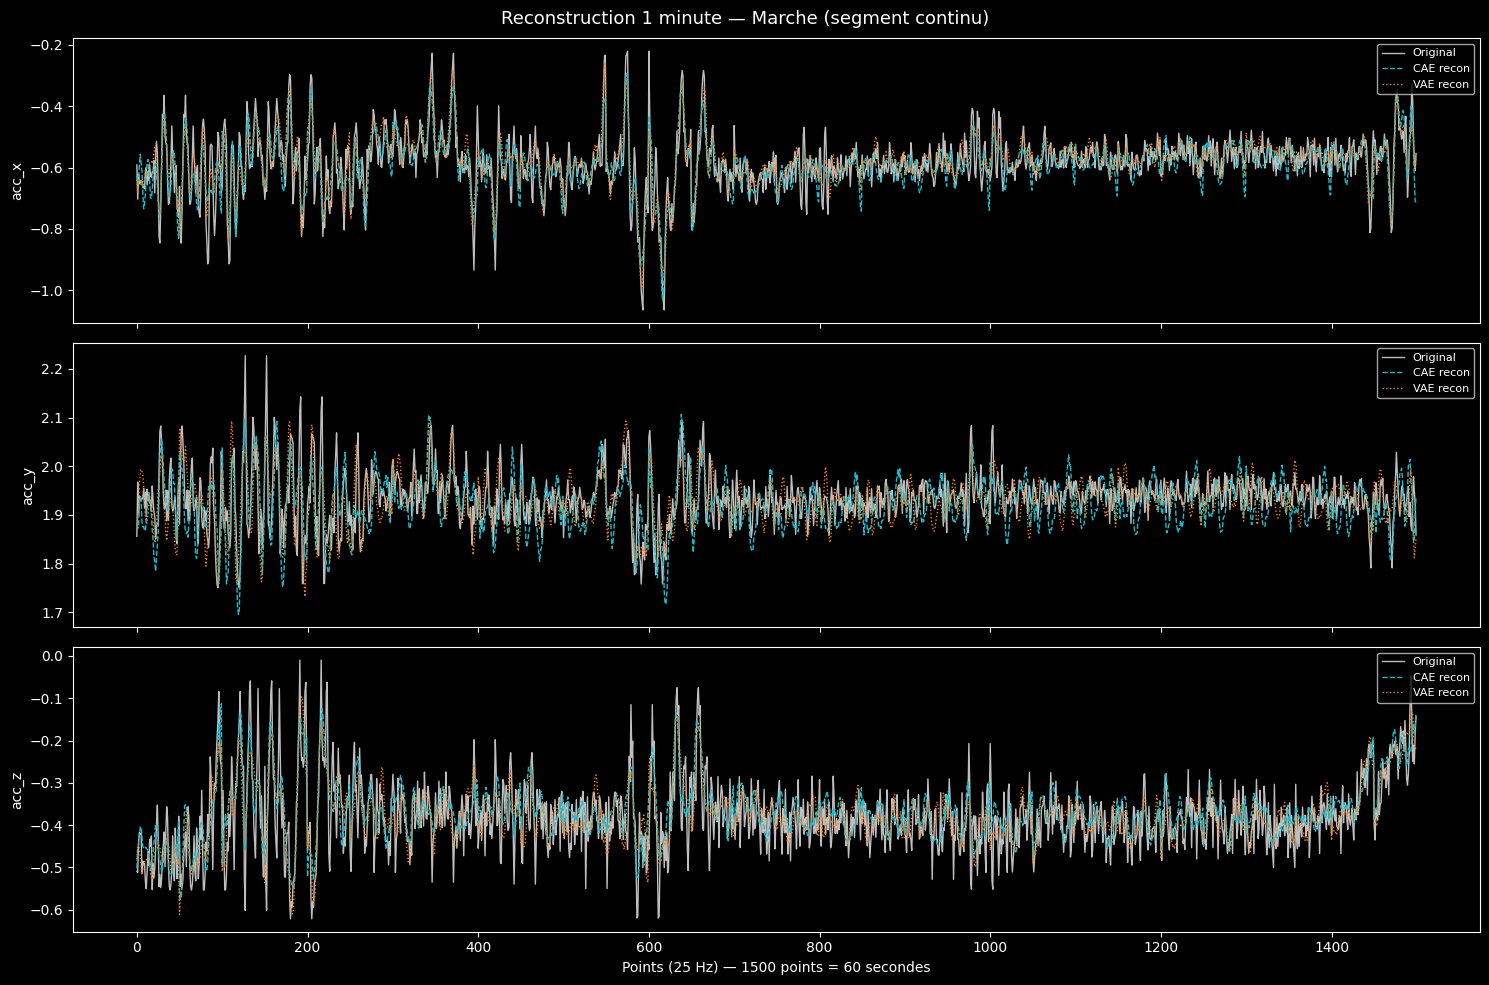

In [10]:
# Reconstruction CAE
recon_cae_seg = cae_model.predict(segment_continu, verbose=0)

# Reconstruction VAE
zm_seg, zv_seg = vae_enc.predict(segment_continu, verbose=0)
z_seg          = zm_seg + 0.1 * np.exp(0.5 * zv_seg) * np.random.normal(size=zm_seg.shape)
recon_vae_seg  = vae_dec.predict(z_seg.astype(np.float32), verbose=0)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"Reconstruction 1 minute — {LABEL_NAME} (segment continu)", fontsize=13)

for j, ax in enumerate(axes):
    orig  = segment_continu[:, :, j].flatten()
    r_cae = recon_cae_seg[:, :, j].flatten()
    r_vae = recon_vae_seg[:, :, j].flatten()

    ax.plot(orig,  label="Original",  color='white',      alpha=0.75, linewidth=1)
    ax.plot(r_cae, label="CAE recon", color='tab:cyan',   linestyle='--', linewidth=1)
    ax.plot(r_vae, label="VAE recon", color='tab:orange', linestyle=':',  linewidth=1)
    ax.set_ylabel(axis_names[j])
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel("Points (25 Hz) — 1500 points = 60 secondes")
plt.tight_layout()
plt.show()

## 10. Génération synthétique VAE — 1 minute de signal pur

On caractérise le cluster de l'activité cible dans l'espace latent
(centre + dispersion), puis on tire 30 vecteurs dedans et on décode.
Aucun signal réel en entrée — pure génération.

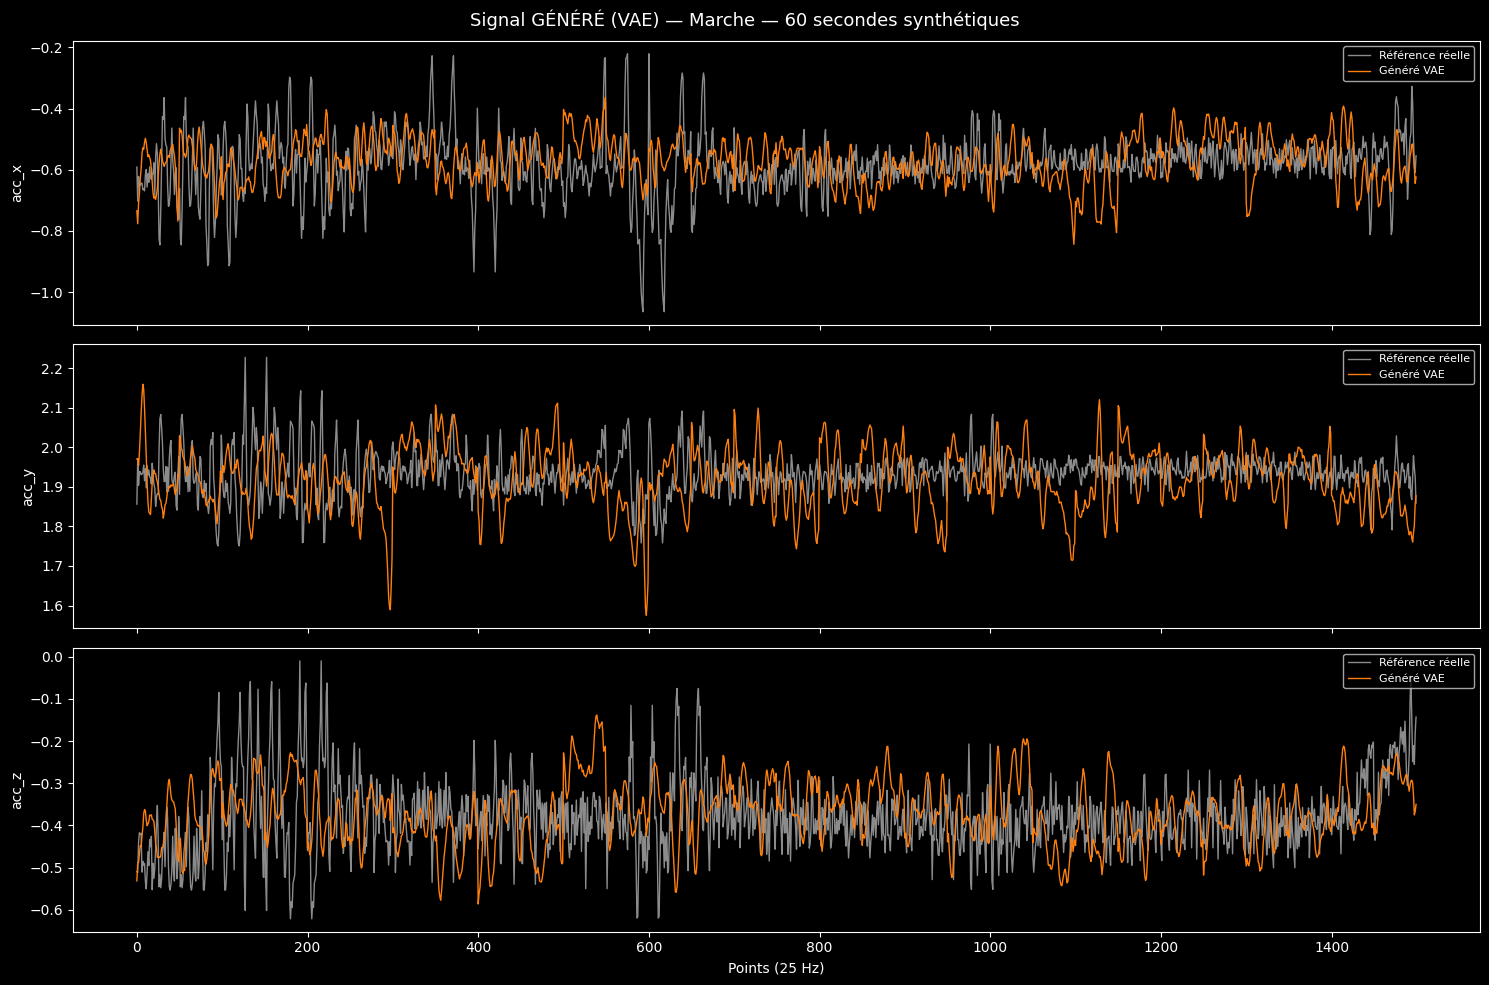

In [11]:
# Caractériser la zone latente de l'activité cible
# On utilise z_mean (déterministe) pour estimer le centre du cluster
zm_label, _ = vae_enc.predict(segment_continu, verbose=0)
z_centre     = np.mean(zm_label, axis=0)  # (32,)
z_std_label  = np.std(zm_label,  axis=0)  # (32,)

# Générer N_WINDOWS vecteurs latents dans la zone du label cible
z_generated   = np.random.normal(
    loc=z_centre, scale=z_std_label, size=(N_WINDOWS, latent_dim)
).astype(np.float32)

signal_genere = vae_dec.predict(z_generated, verbose=0)  # (30, 50, 3)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
fig.suptitle(f"Signal GÉNÉRÉ (VAE) — {LABEL_NAME} — 60 secondes synthétiques", fontsize=13)

for j, ax in enumerate(axes):
    orig = segment_continu[:, :, j].flatten()
    gen  = signal_genere[:, :, j].flatten()

    ax.plot(orig, label="Référence réelle", color='white',      alpha=0.55, linewidth=1)
    ax.plot(gen,  label="Généré VAE",       color='tab:orange', linewidth=1)
    ax.set_ylabel(axis_names[j])
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel("Points (25 Hz)")
plt.tight_layout()
plt.show()